In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

df = pd.read_csv("CarPrice_Assignment (1).csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [45]:
df.shape

(205, 26)

In [46]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [48]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df["brand"] = df["CarName"].str.split().str[0].str.lower()

df[["CarName", "brand"]].head()

,CarName,brand
0,alfa-romero giulia,alfa-romero
1,alfa-romero stelvio,alfa-romero
2,alfa-romero Quadrifoglio,alfa-romero
3,audi 100 ls,audi
4,audi 100ls,audi


In [51]:
df = df.drop(["CarName", "car_ID"], axis=1)

df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [52]:
X = df.drop("price", axis=1)
y = df["price"]

In [53]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'brand'],
      dtype='object')

Numerical Columns:
Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (164, 24)
Testing data: (41, 24)


In [55]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numerical_cols),("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)])

In [56]:
linear_model = Pipeline([("preprocessor", preprocessor),("model", LinearRegression())])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression")
print("R2 Score:", linear_r2)
print("MSE:", linear_mse)
print("MAE:", linear_mae)

Linear Regression
R2 Score: 0.8998428477829612
MSE: 7906808.315868961
MAE: 1835.3280361978555


In [57]:
dt_model = Pipeline([("preprocessor", preprocessor),("model", DecisionTreeRegressor(random_state=42))])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)

print("Decision Tree Regressor")
print("R2 Score:", dt_r2)
print("MSE:", dt_mse)
print("MAE:", dt_mae)

Decision Tree Regressor
R2 Score: 0.9135993177926663
MSE: 6820817.260192415
MAE: 1704.142268292683


In [58]:
rf_model = Pipeline([("preprocessor", preprocessor),("model", RandomForestRegressor(n_estimators=200,random_state=42))])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regressor")
print("R2 Score:", rf_r2)
print("MSE:", rf_mse)
print("MAE:", rf_mae)

Random Forest Regressor
R2 Score: 0.9577590826487904
MSE: 3334667.861349787
MAE: 1287.1849207317075


In [59]:
gb_model = Pipeline([("preprocessor", preprocessor),("model", GradientBoostingRegressor(random_state=42))])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("R2 Score:", gb_r2)
print("MSE:", gb_mse)
print("MAE:", gb_mae)

Gradient Boosting Regressor
R2 Score: 0.9281616246171772
MSE: 5671210.206182246
MAE: 1690.9487058002492


In [60]:
svr_model = Pipeline([("preprocessor", preprocessor),("model", SVR())])

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)

svr_r2 = r2_score(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)

print("Support Vector Regressor")
print("R2 Score:", svr_r2)
print("MSE:", svr_mse)
print("MAE:", svr_mae)

Support Vector Regressor
R2 Score: -0.09979003251746388
MSE: 86821847.29029806
MAE: 5695.273987221687


In [61]:
results = pd.DataFrame({"Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"],
    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2],
    "MSE": [
        linear_mse,
        dt_mse,
        rf_mse,
        gb_mse,
        svr_mse],
    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae]})

results

,Model,R2 Score,MSE,MAE
0,Linear Regression,0.899843,7.906808e+06,1835.328036
1,Decision Tree,0.913599,6.820817e+06,1704.142268
2,Random Forest,0.957759,3.334668e+06,1287.184921
3,Gradient Boosting,0.928162,5.671210e+06,1690.948706
4,SVR,-0.099790,8.682185e+07,5695.273987


In [62]:
#Random Forest Regressor is the best-performing model because:

#Highest R² score
#Lowest MSE
#Lowest MAE

In [63]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = rf_estimator.feature_importances_

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": importance})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

feature_importance.head(15)

,Feature,Importance
6,num__enginesize,0.575433
5,num__curbweight,0.271665
13,num__highwaympg,0.044571
10,num__horsepower,0.026734
3,num__carwidth,0.012659
2,num__carlength,0.008565
53,cat__brand_bmw,0.007164
1,num__wheelbase,0.007154
12,num__citympg,0.006675
11,num__peakrpm,0.005398


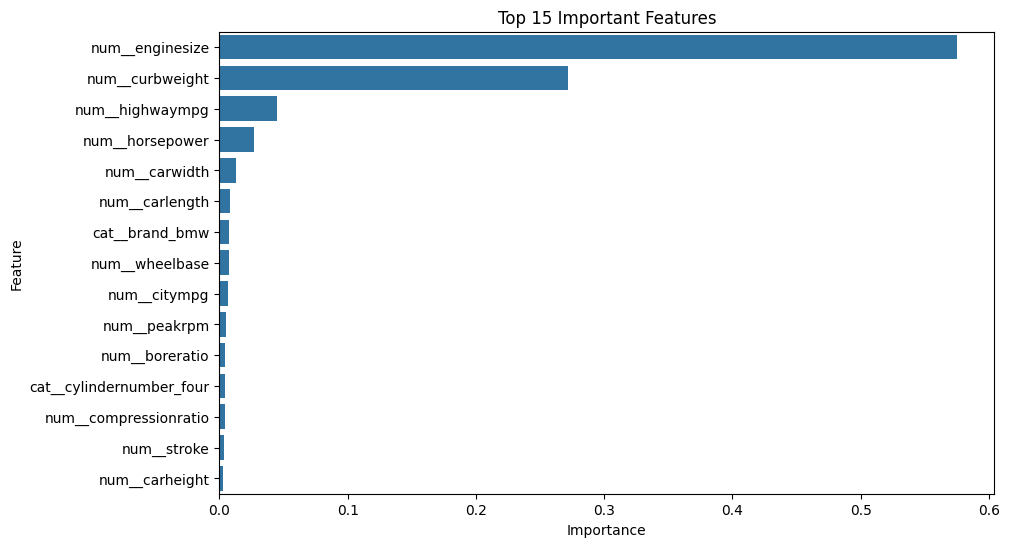

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature")

plt.title("Top 15 Important Features")
plt.show()

In [65]:
rf_tuning = Pipeline([("preprocessor", preprocessor),("model", RandomForestRegressor(random_state=42))])

In [66]:
param_grid = {"model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 15],
    "model__min_samples_split": [2, 5]}

In [ ]:
grid_search = GridSearchCV(rf_tuning,param_grid,cv=5,scoring="r2",n_jobs=-1)

grid_search.fit(X_train, y_train)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

In [ ]:
tuned_pred = grid_search.predict(X_test)

tuned_r2 = r2_score(y_test, tuned_pred)
tuned_mse = mean_squared_error(y_test, tuned_pred)
tuned_mae = mean_absolute_error(y_test, tuned_pred)

print("Tuned Random Forest")
print("R2 Score:", tuned_r2)
print("MSE:", tuned_mse)
print("MAE:", tuned_mae)

In [ ]:
comparison = pd.DataFrame({"Model": ["Random Forest", "Tuned Random Forest"],"R2 Score": [rf_r2, tuned_r2],
    "MSE": [rf_mse, tuned_mse],
    "MAE": [rf_mae, tuned_mae]})

comparison